In [1]:
import numpy as np 
import pandas as pd 

df = pd.read_csv("D:\\Deep Learning\\Churn_Modelling.csv")
df 



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [2]:
df.duplicated().sum()

np.int64(0)

In [3]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [4]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [5]:

df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [6]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Now convert categorical data into Numerical data (0,1)

In [9]:
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [10]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [13]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [14]:
X_train.shape

(8000, 11)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled 

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [21]:
import tensorflow 
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [22]:
model = Sequential() # --> object of ANN

model.add(Dense(3, activation='sigmoid', input_dim = 11)) # --> input layer and first hidden layer
model.add(Dense(1, activation='sigmoid')) # --> output layer


c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='adam', loss='binary_crossentropy')

In [25]:
model.fit(X_train_scaled, y_train, epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5537
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4891
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4663
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4551
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4477
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4422
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4381
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4352
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4329
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4312


In [26]:
model.layers[0].get_weights()

[array([[ 0.20904148,  0.22993511, -0.07153585],
        [ 0.5365207 , -1.19176   , -1.7903839 ],
        [-0.5385743 ,  0.07405511, -0.17008512],
        [ 0.58366877, -0.267694  , -0.02350389],
        [-0.42105392,  0.04263227,  0.11837126],
        [-0.05161919,  0.09242871, -0.210603  ],
        [-0.6878158 ,  0.57608134,  0.5906288 ],
        [-0.04001469, -0.0482344 ,  0.02398969],
        [ 0.4073802 , -0.5323073 , -0.4187273 ],
        [-0.31463018, -0.2407105 ,  0.27394885],
        [-0.47978187,  0.32970554,  0.5343418 ]], dtype=float32),
 array([-0.2913203 ,  0.292315  ,  0.42684305], dtype=float32)]

In [27]:
model.layers[1].get_weights()

[array([[ 0.50355995],
        [-1.6895939 ],
        [-1.054837  ]], dtype=float32),
 array([-0.25248522], dtype=float32)]

In [30]:
y_log = model.predict(X_test_scaled)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.1944888 ],
       [0.08997755],
       [0.3041206 ],
       ...,
       [0.3473377 ],
       [0.07692529],
       [0.191665  ]], shape=(2000, 1), dtype=float32)

In [32]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [48]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.812

If you want to improve your accuracy_score then increase
1: increase epochs
2: instead of sigmoid use ReLu
3: increase the hidden layer nodes 
4: increase  the hidden layer
 

Now create a graph show clear 

In [41]:
history = model.fit(X_train_scaled, y_train, epochs=100 , validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4193 - val_loss: 0.4092
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4190 - val_loss: 0.4089
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4185 - val_loss: 0.4086
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4182 - val_loss: 0.4084
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4179 - val_loss: 0.4081
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4175 - val_loss: 0.4079
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4172 - val_loss: 0.4076
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4169 - val_loss: 0.4074
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4166 - val_loss: 0.4072
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4163 - val_loss: 0.4070
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4160 - val_loss: 0.4067
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

In [49]:
import matplotlib.pyplot as plt

In [50]:
history.history

{'loss': [0.4192824065685272,
  0.41895949840545654,
  0.4185171127319336,
  0.41822680830955505,
  0.4178983271121979,
  0.4175356924533844,
  0.41719943284988403,
  0.4168696999549866,
  0.4165615439414978,
  0.4163002371788025,
  0.4160097539424896,
  0.4157608449459076,
  0.4155460298061371,
  0.41525647044181824,
  0.41500598192214966,
  0.41482093930244446,
  0.41454261541366577,
  0.4143696129322052,
  0.4141378700733185,
  0.4139973521232605,
  0.41379502415657043,
  0.4136185944080353,
  0.4133901596069336,
  0.4132348597049713,
  0.4130167067050934,
  0.4129182696342468,
  0.4127514660358429,
  0.41257965564727783,
  0.4124566316604614,
  0.4122648239135742,
  0.41216418147087097,
  0.4120364487171173,
  0.4118892252445221,
  0.4116913974285126,
  0.41164958477020264,
  0.411515474319458,
  0.41135719418525696,
  0.41128018498420715,
  0.4111729562282562,
  0.4110269844532013,
  0.41091153025627136,
  0.4108216464519501,
  0.41071826219558716,
  0.41069167852401733,
  0.41054

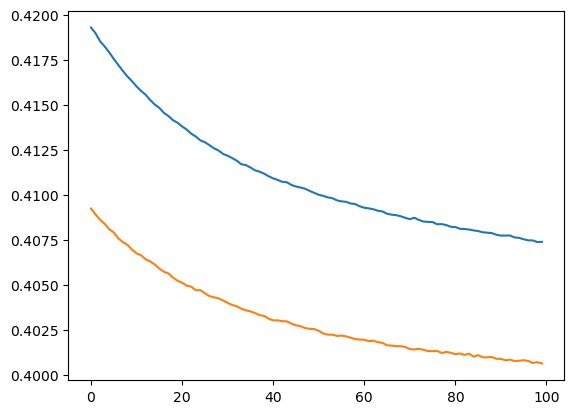

In [51]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])